In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import logit
from scipy.optimize import minimize
from tqdm import tqdm

# append paths
sys.path.append('../../')

# local imports
from process.tables import *
from models.bayes import *
from process.config import *
from process.measurements import cutoff_measurements_df



In [62]:
lab_measurements = pd.read_csv('../../data/processed/lab_measurements.csv')
predictions = pd.read_csv('predictions/test_predictions.csv')
predictions['prediction'] = np.where(predictions['condition'] == 0, predictions['pred_unhealthy'], predictions['pred_healthy'])
predictions['variance'] = np.where(predictions['condition'] == 0, predictions['pred_unhealthy_var'], predictions['pred_healthy_var'])
predictions

,patient_id,subject_id,test_name,prediction,variance,target,condition,pred_healthy,pred_unhealthy,pred_healthy_var,...,hp_nhead,hp_num_layers,hp_decoder_type,hp_batch_size,hp_lr,hp_epochs,hp_lambda_align,model_type,decoder_type,timestamp
0,test_batch_0_sample_0,115967202,0,11.434628,2.177314,10.800000,0,13.518577,11.434628,0.735624,...,2,2,gaussian,32,0.001,5,0.1,dual_mode,gaussian,2025-08-11T16:47:28.867457
1,test_batch_0_sample_1,115968654,0,10.740976,3.798280,13.700000,0,15.028676,10.740976,0.840443,...,2,2,gaussian,32,0.001,5,0.1,dual_mode,gaussian,2025-08-11T16:47:28.867457
2,test_batch_0_sample_2,115971090,0,11.819348,2.610901,13.100000,0,14.725090,11.819348,0.540081,...,2,2,gaussian,32,0.001,5,0.1,dual_mode,gaussian,2025-08-11T16:47:28.867457
3,test_batch_0_sample_3,115967983,0,10.793000,2.850159,9.700000,0,15.128678,10.793000,0.758741,...,2,2,gaussian,32,0.001,5,0.1,dual_mode,gaussian,2025-08-11T16:47:28.867457
4,test_batch_0_sample_4,115970203,0,11.343030,3.517390,11.500000,0,15.250537,11.343030,0.991143,...,2,2,gaussian,32,0.001,5,0.1,dual_mode,gaussian,2025-08-11T16:47:28.867457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,test_batch_31_sample_2,115970692,0,10.571450,2.595728,10.300000,0,14.533278,10.571450,0.662564,...,2,2,gaussian,32,0.001,5,0.1,dual_mode,gaussian,2025-08-11T16:47:28.867457
995,test_batch_31_sample_3,115971110,0,11.367986,4.660924,8.400000,0,14.899745,11.367986,1.106895,...,2,2,gaussian,32,0.001,5,0.1,dual_mode,gaussian,2025-08-11T16:47:28.867457
996,test_batch_31_sample_4,115969498,0,14.147740,1.039598,17.200001,1,14.147740,10.499369,1.039598,...,2,2,gaussian,32,0.001,5,0.1,dual_mode,gaussian,2025-08-11T16:47:28.867457
997,test_batch_31_sample_5,115969449,0,13.440961,0.755802,14.200000,1,13.440961,10.668723,0.755802,...,2,2,gaussian,32,0.001,5,0.1,dual_mode,gaussian,2025-08-11T16:47:28.867457


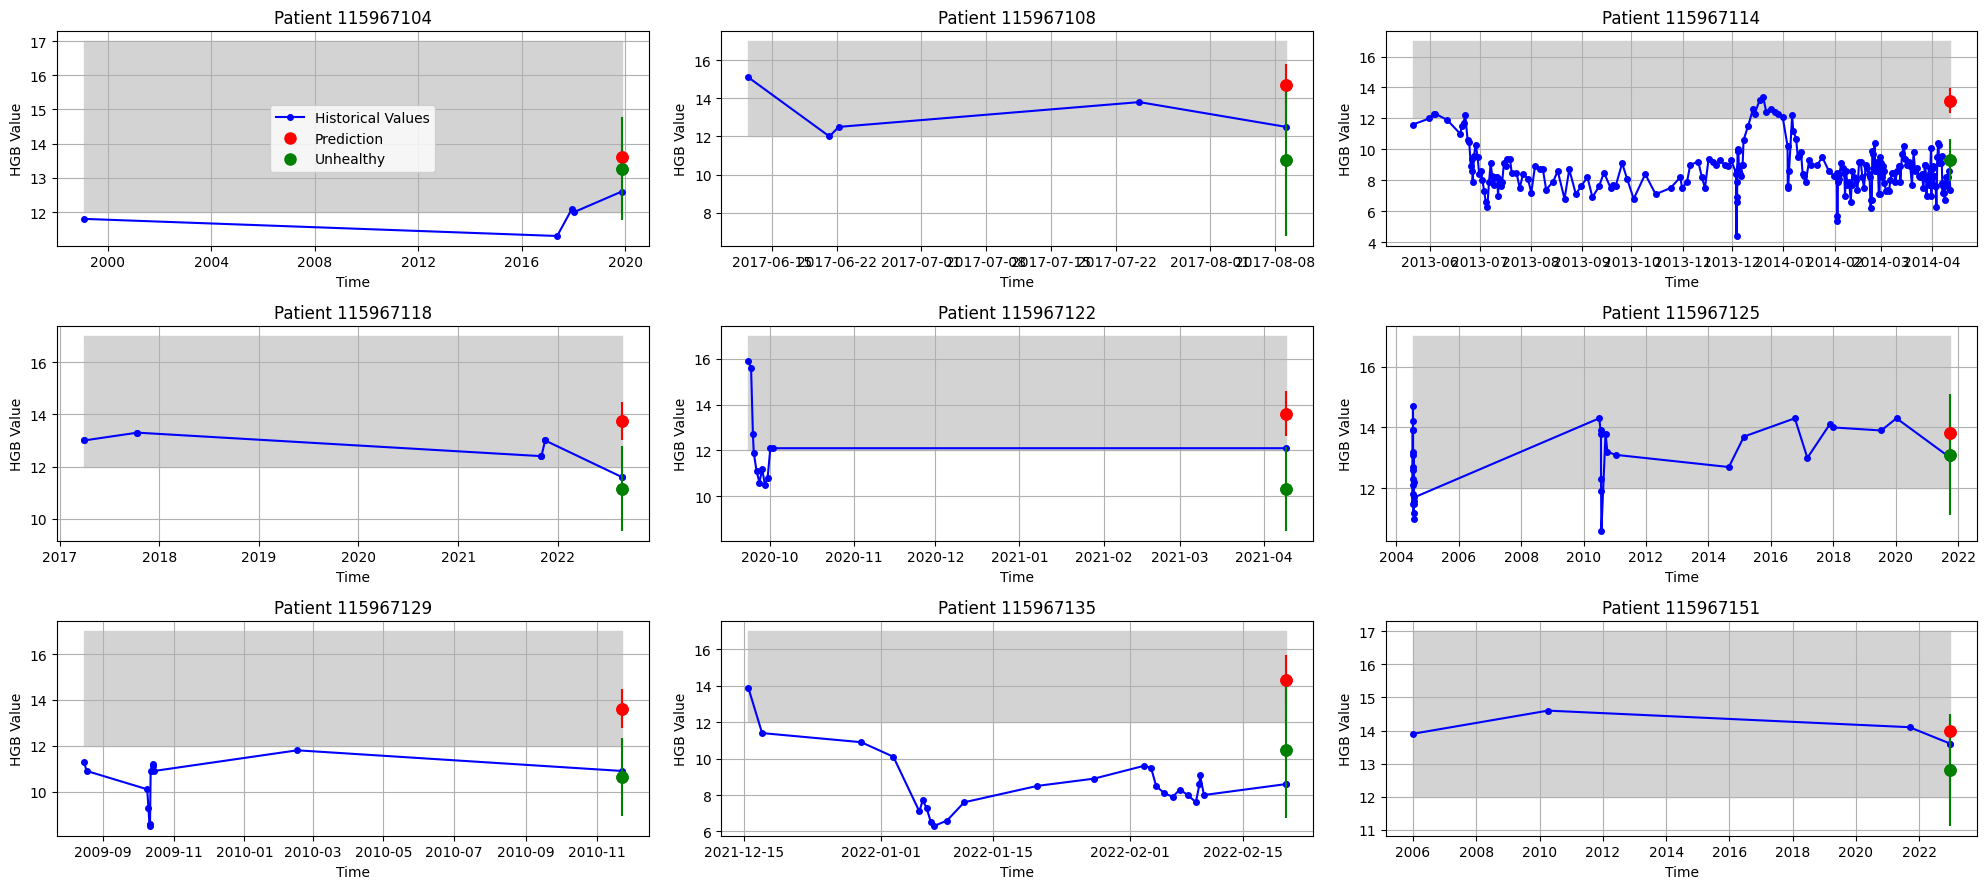

In [ ]:
# Get number of samples to plot
n_samples = 9
n_cols = 3  # Plot 2 columns
n_rows = (n_samples + n_cols - 1) // n_cols  # Calculate rows needed to fit n_samples

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))
axes = axes.ravel()

# Get first n_samples unique patient/test combinations
groups = predictions.groupby(['subject_id', 'test_name'])
for i, ((patient_id, test_name), group) in enumerate(list(groups)[:n_samples]):
    
    # Get patient history
    history = lab_measurements[
        (lab_measurements['subject_id'] == patient_id) & 
        (lab_measurements['test_name'] == 'HGB')
    ]
    
    # shade 12 and above with a light grey because that's the reference range
    axes[i].fill_between(pd.to_datetime(history['time']), 12, 17, color='lightgrey')
    
    # Plot in current subplot
    axes[i].plot(pd.to_datetime(history['time']), history['numeric_value'],
                'bo-', label='Historical Values', markersize=4)
    
    last_time = pd.to_datetime(history['time'].iloc[-1])
    axes[i].plot(last_time, group['pred_healthy'].iloc[0],
                'ro', label='Healthy', markersize=8)
    # create error bars for original prediction
    axes[i].errorbar(last_time, group['pred_healthy'].iloc[0], yerr=group['pred_healthy_var'].iloc[0],
                    fmt='ro', markersize=8)
    
    # create error bars for counterfactual prediction
    axes[i].errorbar(last_time, group['pred_unhealthy'].iloc[0], yerr=group['pred_unhealthy_var'].iloc[0],
                    fmt='go', markersize=8)  
    axes[i].plot(last_time, group['pred_unhealthy'].iloc[0],
                'go', label='Unhealthy', markersize=8)
    
    axes[i].set_title(f'Patient {patient_id}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('HGB Value')
    axes[i].grid(True)
    
    if i == 0:  # Only show legend for first subplot
        axes[i].legend()

# Hide any empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Predictions vs Targets by Condition')

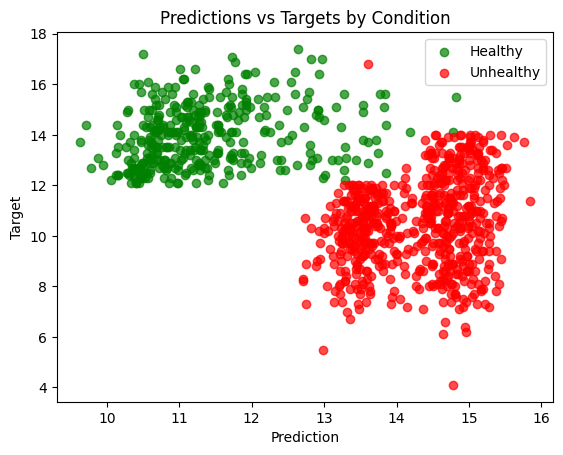

In [61]:
healthy_mask = predictions['condition'] == 1
unhealthy_mask = predictions['condition'] == 0

plt.scatter(predictions.loc[healthy_mask, 'prediction'], 
            predictions.loc[healthy_mask, 'target'], 
            color='green', label='Healthy', alpha=0.7)
plt.scatter(predictions.loc[unhealthy_mask, 'prediction'], 
            predictions.loc[unhealthy_mask, 'target'], 
            color='red', label='Unhealthy', alpha=0.7)

plt.legend()
plt.xlabel('Prediction')
plt.ylabel('Target')
plt.title('Predictions vs Targets by Condition')

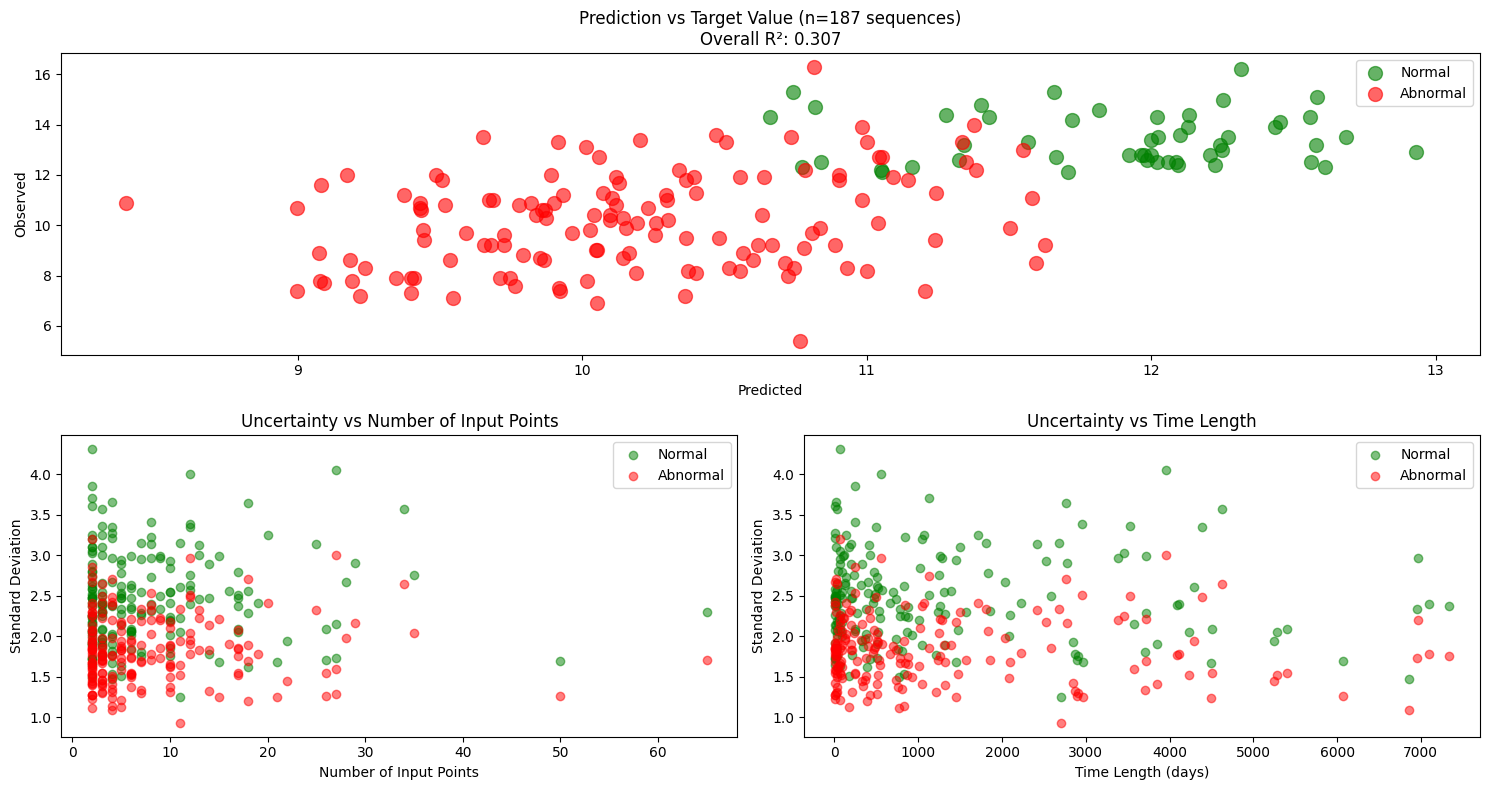

In [9]:
from sklearn.metrics import r2_score

# Calculate time length and input std for each sequence
time_lengths = []
input_stds = []
for idx, row in predictions.iterrows():
    # Get times
    input_times_str = row['input_times'].strip('[]').replace("'", "").split(',')
    input_times_str = [s.strip() for s in input_times_str]
    input_times = [pd.Timestamp(ts.replace('Timestamp(', '').replace(')', '')) for ts in input_times_str]
    time_length = (input_times[-1] - input_times[0]).total_seconds() / (60 * 60 * 24) # Convert to days
    time_lengths.append(time_length)
    
    # Get std of input values
    input_values = np.fromstring(row['input_values'].strip('[]'), sep=' ')
    input_stds.append(np.std(input_values) if len(input_values) > 1 else 0)

predictions['time_length'] = time_lengths
predictions['input_std'] = input_stds
predictions['points_per_day'] = predictions['num_input_points'] / predictions['time_length']

# Fit regression models for uncertainty analysis
from sklearn.linear_model import LinearRegression

# For normal predictions
X_normal = np.column_stack([
    predictions['num_input_points'],
    predictions['time_length'],
    predictions['input_std']
])
y_normal = predictions['std_healthy']
model_normal = LinearRegression().fit(X_normal, y_normal)

# For abnormal predictions  
X_abnormal = np.column_stack([
    predictions['num_input_points'],
    predictions['time_length'],
    predictions['input_std']
])
y_abnormal = predictions['std_unhealthy']
model_abnormal = LinearRegression().fit(X_abnormal, y_abnormal)

# Create figure with 2 rows
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# Top plot - predictions vs actual
ax0 = fig.add_subplot(gs[0, :])

# Create separate scatter plots for normal and abnormal points
normal_mask = predictions['actual_target_health'] == 1
abnormal_mask = predictions['actual_target_health'] == 0

ax0.scatter(predictions[normal_mask]['true_prediction'],
           predictions[normal_mask]['target'],
           c='green', label='Normal', alpha=0.6, s=100)

ax0.scatter(predictions[abnormal_mask]['true_prediction'],
           predictions[abnormal_mask]['target'],
           c='red', label='Abnormal', alpha=0.6, s=100)

# Calculate R² for healthy and unhealthy separately
r2_healthy = r2_score(predictions[normal_mask]['target'], predictions[normal_mask]['true_prediction'])
healthy_df = predictions.query('actual_target_health == 1')
unhealthy_df = predictions.query('actual_target_health == 0')
#r2_healthy = r2_score(healthy_df['target'], healthy_df['true_prediction'])
#r2_unhealthy = r2_score(unhealthy_df['target'], unhealthy_df['true_prediction'])
r2_overall = r2_score(predictions['target'], predictions['true_prediction'])

ax0.set_xlabel('Predicted')
ax0.set_ylabel('Observed')
ax0.set_title(f'Prediction vs Target Value (n={len(predictions)} sequences)\nOverall R²: {r2_overall:.3f}') #, Healthy R²: {r2_healthy:.3f}, Unhealthy R²: {r2_unhealthy:.3f}')
ax0.legend()

# Bottom left - Number of points vs std
ax1 = fig.add_subplot(gs[1, 0])
ax1.scatter(predictions['num_input_points'], predictions['std_healthy'], alpha=0.5, label='Normal', c='green')
ax1.scatter(predictions['num_input_points'], predictions['std_unhealthy'], alpha=0.5, label='Abnormal', c='red')
ax1.set_xlabel('Number of Input Points')
ax1.set_ylabel('Standard Deviation')
ax1.legend()
ax1.set_title('Uncertainty vs Number of Input Points')

# Bottom right - Time length vs std
ax2 = fig.add_subplot(gs[1, 1])
ax2.scatter(predictions['time_length'], predictions['std_healthy'], alpha=0.5, label='Normal', c='green')
ax2.scatter(predictions['time_length'], predictions['std_unhealthy'], alpha=0.5, label='Abnormal', c='red')
ax2.set_xlabel('Time Length (days)')
ax2.set_ylabel('Standard Deviation')
ax2.legend()
ax2.set_title('Uncertainty vs Time Length')

plt.tight_layout()
plt.show()


In [58]:
# load the results
results = pd.read_csv('../. /norma/model_summary_health_nll_sample_0.3.csv')
predictions = pd.read_csv('../../results/norma/test_predictions_health_nll_sample_0.3.csv')
health_predictions = pd.read_csv('../../results/norma/test_predictions_health_nll_sample_0.3.csv')

predictions = pd.read_csv('predictions/test_predictions_health_nll_sample_0.3.csv')
counterfactual_predictions = pd.read_csv('predictions/counterfactual_predictions.csv')
display(health_predictions)

# Create one figure for all plots
fig, axes = plt.subplots(3, 2, figsize=(20, 8))
axes = axes.ravel()

for patient_id in predictions['patient_id'].unique()[:10]:
    sample_predictions = health_predictions[health_predictions['patient_id'] == patient_id]
    input_values = np.fromstring(sample_predictions['input_values'].iloc[0].strip('[]'), sep=' ')

    # Parse the timestamp strings more carefully
    input_times_str = sample_predictions['input_times'].iloc[0].strip('[]').replace("'", "").split(',')
    input_times_str = [s.strip() for s in input_times_str]  # Remove whitespace
    input_times = [pd.Timestamp(ts.replace('Timestamp(', '').replace(')', '')) for ts in input_times_str]    
    forecast_time = pd.Timestamp(sample_predictions['forecast_time'].iloc[0])
    
    # Plot input values
    axes[count].plot(input_times, input_values, 'bo-', label='Input Values')
    axes[count].plot(forecast_time, sample_predictions['pred_healthy'], 'go', label='Healthy Prediction')
    axes[count].fill_between([forecast_time], 
                           sample_predictions['pred_healthy'] - sample_predictions['std_healthy'],
                           sample_predictions['pred_healthy'] + sample_predictions['std_healthy'], 
                           alpha=0.5, color='green', label='Healthy Uncertainty')

    axes[count].plot(forecast_time, sample_predictions['pred_unhealthy'], 'ro', label='Unhealthy Prediction')
    axes[count].fill_between([forecast_time],
                           sample_predictions['pred_unhealthy'] - sample_predictions['std_unhealthy'],
                           sample_predictions['pred_unhealthy'] + sample_predictions['std_unhealthy'],
                           alpha=0.5, color='red', label='Unhealthy Uncertainty')

    axes[count].plot(forecast_time, sample_predictions['target'], 'bo', label='True Value')
    
    axes[count].set_title(f'Patient {patient_id}')
    axes[count].set_xlabel('Time')
    axes[count].set_ylabel('HGB Value')
    
    if count == 0:  # Add legend above the entire plot
        fig.legend(bbox_to_anchor=(0.5, 1.05), loc='upper center', ncol=6, frameon=False)
    count += 1

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../. /norma/model_summary_health_nll_sample_0.3.csv'

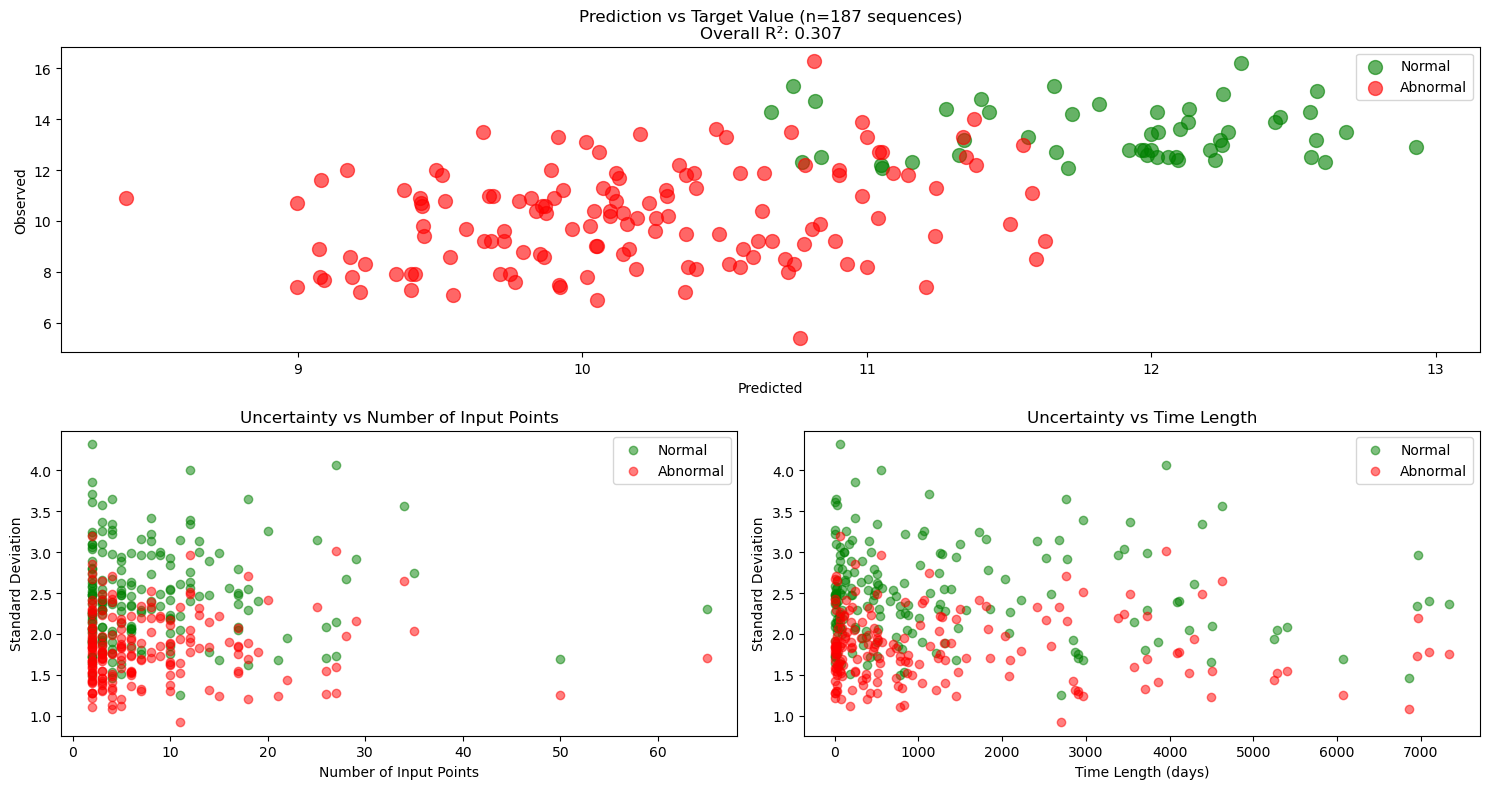

In [148]:
# plot the target value vs the true prediction value for the actual health status

# load the predictions
predictions = pd.read_csv('../../results/norma/test_predictions_health_nll_sample_0.1.csv')
from sklearn.metrics import r2_score

# Calculate time length and input std for each sequence
time_lengths = []
input_stds = []
for idx, row in predictions.iterrows():
    # Get times
    input_times_str = row['input_times'].strip('[]').replace("'", "").split(',')
    input_times_str = [s.strip() for s in input_times_str]
    input_times = [pd.Timestamp(ts.replace('Timestamp(', '').replace(')', '')) for ts in input_times_str]
    time_length = (input_times[-1] - input_times[0]).total_seconds() / (60 * 60 * 24) # Convert to days
    time_lengths.append(time_length)
    
    # Get std of input values
    input_values = np.fromstring(row['input_values'].strip('[]'), sep=' ')
    input_stds.append(np.std(input_values) if len(input_values) > 1 else 0)

predictions['time_length'] = time_lengths
predictions['input_std'] = input_stds
predictions['points_per_day'] = predictions['num_input_points'] / predictions['time_length']

# Fit regression models for uncertainty analysis
from sklearn.linear_model import LinearRegression

# For normal predictions
X_normal = np.column_stack([
    predictions['num_input_points'],
    predictions['time_length'],
    predictions['input_std']
])
y_normal = predictions['std_healthy']
model_normal = LinearRegression().fit(X_normal, y_normal)

# For abnormal predictions  
X_abnormal = np.column_stack([
    predictions['num_input_points'],
    predictions['time_length'],
    predictions['input_std']
])
y_abnormal = predictions['std_unhealthy']
model_abnormal = LinearRegression().fit(X_abnormal, y_abnormal)

# Create figure with 2 rows
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# Top plot - predictions vs actual
ax0 = fig.add_subplot(gs[0, :])

# Create separate scatter plots for normal and abnormal points
normal_mask = predictions['actual_target_health'] == 1
abnormal_mask = predictions['actual_target_health'] == 0

ax0.scatter(predictions[normal_mask]['true_prediction'],
           predictions[normal_mask]['target'],
           c='green', label='Normal', alpha=0.6, s=100)

ax0.scatter(predictions[abnormal_mask]['true_prediction'],
           predictions[abnormal_mask]['target'],
           c='red', label='Abnormal', alpha=0.6, s=100)

# Calculate R² for healthy and unhealthy separately
r2_healthy = r2_score(predictions[normal_mask]['target'], predictions[normal_mask]['true_prediction'])
healthy_df = predictions.query('actual_target_health == 1')
unhealthy_df = predictions.query('actual_target_health == 0')
#r2_healthy = r2_score(healthy_df['target'], healthy_df['true_prediction'])
#r2_unhealthy = r2_score(unhealthy_df['target'], unhealthy_df['true_prediction'])
r2_overall = r2_score(predictions['target'], predictions['true_prediction'])

ax0.set_xlabel('Predicted')
ax0.set_ylabel('Observed')
ax0.set_title(f'Prediction vs Target Value (n={len(predictions)} sequences)\nOverall R²: {r2_overall:.3f}') #, Healthy R²: {r2_healthy:.3f}, Unhealthy R²: {r2_unhealthy:.3f}')
ax0.legend()

# Bottom left - Number of points vs std
ax1 = fig.add_subplot(gs[1, 0])
ax1.scatter(predictions['num_input_points'], predictions['std_healthy'], alpha=0.5, label='Normal', c='green')
ax1.scatter(predictions['num_input_points'], predictions['std_unhealthy'], alpha=0.5, label='Abnormal', c='red')
ax1.set_xlabel('Number of Input Points')
ax1.set_ylabel('Standard Deviation')
ax1.legend()
ax1.set_title('Uncertainty vs Number of Input Points')

# Bottom right - Time length vs std
ax2 = fig.add_subplot(gs[1, 1])
ax2.scatter(predictions['time_length'], predictions['std_healthy'], alpha=0.5, label='Normal', c='green')
ax2.scatter(predictions['time_length'], predictions['std_unhealthy'], alpha=0.5, label='Abnormal', c='red')
ax2.set_xlabel('Time Length (days)')
ax2.set_ylabel('Standard Deviation')
ax2.legend()
ax2.set_title('Uncertainty vs Time Length')

plt.tight_layout()
plt.show()


In [ ]:
pd.read_csv('../../results/norma/test_predictions_health_nll_sample_0.1.csv')

In [74]:
pd.read_csv('../../results/norma/model_summary_health_nll_sample_0.1.csv')

,loss_type,mse_healthy,mae_healthy,mse_unhealthy,mae_unhealthy,mse_overall,mae_overall,auc_healthy,auc_unhealthy,num_test_samples,model_parameters,avg_std_healthy,avg_std_unhealthy
0,nll,10.7983,2.700831,5.571273,1.991144,2.525551,1.298476,0.535401,0.535401,187,551035,1.594158,1.62855
